# 3. Huấn luyện mô hình

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import sys
from pathlib import Path
import json

In [2]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Thêm src vào path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [3]:
processed_dir = project_root / 'data' / 'processed'

X_train_balanced = pd.read_pickle(processed_dir / 'X_train_balanced.pkl')
X_test = pd.read_pickle(processed_dir / 'X_test.pkl')
y_train_balanced = pd.read_pickle(processed_dir / 'y_train_balanced.pkl')
y_test = pd.read_pickle(processed_dir / 'y_test.pkl')

# Load feature names
with open(processed_dir / 'feature_names.txt', 'r') as f:
    feature_names = [line.strip() for line in f.readlines()]

# Load SMOTE info
with open(processed_dir / 'smote_info.json', 'r') as f:
    info = json.load(f)

print(f"\nData đã load:")
print(f"   X_train: {X_train_balanced.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_train: {y_train_balanced.shape}")
print(f"   y_test: {y_test.shape}")
print(f"   Features: {len(feature_names)}")
print(f"\nInfo:")
print(f"   Train size: {info['train_size_balanced']}")
print(f"   Test size: {info['test_size']}")
print(f"   Target distribution: {info['target_distribution']}")


Data đã load:
   X_train: (361110, 24)
   X_test: (51070, 24)
   y_train: (361110,)
   y_test: (51070,)
   Features: 24

Info:
   Train size: 361110
   Test size: 51070
   Target distribution: {'0': 0.8838717509898295, '1': 0.11612824901017048}


In [4]:
from src.models.train_model import train_and_save_pipeline

print("Đã import các hàm cần thiết!")

Đã import các hàm cần thiết!


In [5]:
# Train all models
results, summary_df, best_model_name, best_model, roc_data = train_and_save_pipeline(X_train_balanced, y_train_balanced, X_test, y_test, save_models=True)


Training XGBoost...
Training XGBClassifier completed in 11.96 seconds
AUC=0.731 | F1=0.1857 | Time=12.0s

Training LightGBM...
Training LGBMClassifier completed in 7.92 seconds
AUC=0.728 | F1=0.1986 | Time=7.9s

Training CatBoost...
Training CatBoostClassifier completed in 35.52 seconds
AUC=0.7323 | F1=0.1834 | Time=35.5s

Đã huấn luyện tất cả các mô hình

Đã lưu tất cả các mô hình

Best Model: LightGBM
   F1-Score: 0.1986


In [10]:
print("So sánh hiệu suất các mô hình")

display(summary_df)

# Highlight best model
best_row = summary_df.iloc[0]
print(f"\nBEST MODEL: {best_row['Model']}")
print(f"   Accuracy: {best_row['Accuracy']}")
print(f"   Precision: {best_row['Precision']}")
print(f"   Recall: {best_row['Recall']}")
print(f"   F1-Score: {best_row['F1-Score']}")
print(f"   ROC-AUC: {best_row['ROC-AUC']}")
print(f"   Training Time: {best_row['Time (s)']}s")

So sánh hiệu suất các mô hình


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Time (s)
1,LightGBM,0.8728,0.3698,0.1357,0.1986,0.7280,7.92
0,XGBoost,0.8761,0.3918,0.1217,0.1857,0.7310,11.96
2,CatBoost,0.8771,0.4015,0.1189,0.1834,0.7323,35.52



BEST MODEL: LightGBM
   Accuracy: 0.8728
   Precision: 0.3698
   Recall: 0.1357
   F1-Score: 0.1986
   ROC-AUC: 0.728
   Training Time: 7.92s


ROC curves saved to: d:\Python\AIN701_Group_04\demo\src\reports\figures\roc_curves.png


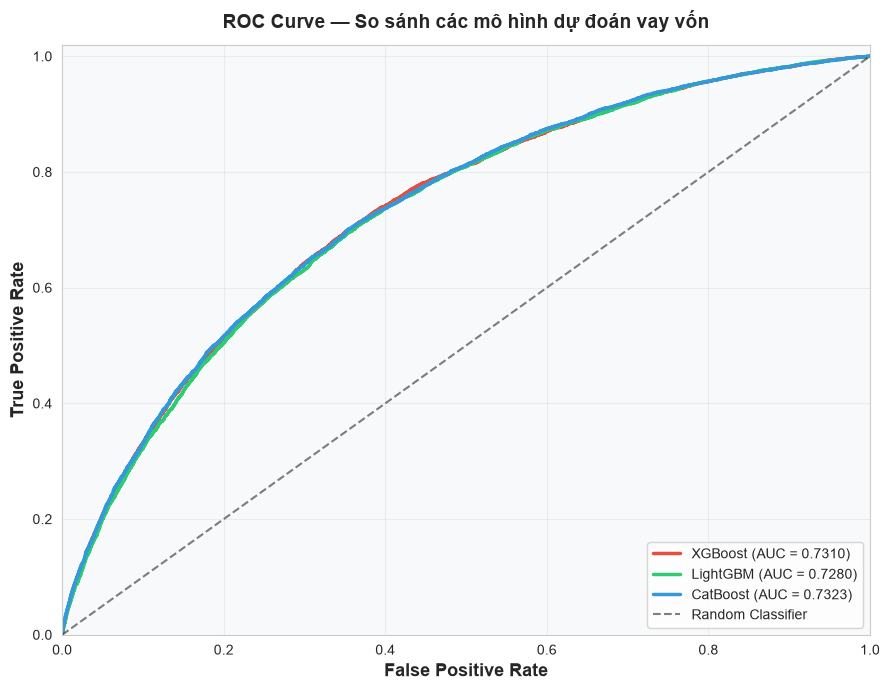

In [15]:
# Định nghĩa màu sắc cho từng model
COLORS = {
    'XGBoost': '#E74C3C',
    'LightGBM': '#2ECC71',
    'CatBoost': '#3498DB'
}

# Thứ tự hiển thị (từ thấp đến cao hoặc theo mong muốn)
MODEL_ORDER = ['XGBoost', 'LightGBM', 'CatBoost']

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(9, 7))
ax.set_facecolor('#F8F9FA')

for name in MODEL_ORDER:
    fpr, tpr, _ = roc_data[name]
    auc = results[name]['metrics']['ROC-AUC']
    ax.plot(fpr, tpr, color=COLORS[name], lw=2.5,
            label=f"{name} (AUC = {auc:.4f})")

ax.plot([0,1],[0,1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')
ax.set_title('ROC Curve — So sánh các mô hình dự đoán vay vốn',
             fontsize=14, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
output_path = project_root / 'src' / 'reports' / 'figures' / 'roc_curves.png'
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"ROC curves saved to: {output_path}")
plt.show()

Figure saved to: d:\Python\AIN701_Group_04\demo\src\reports\figures\confusion_matrices.png


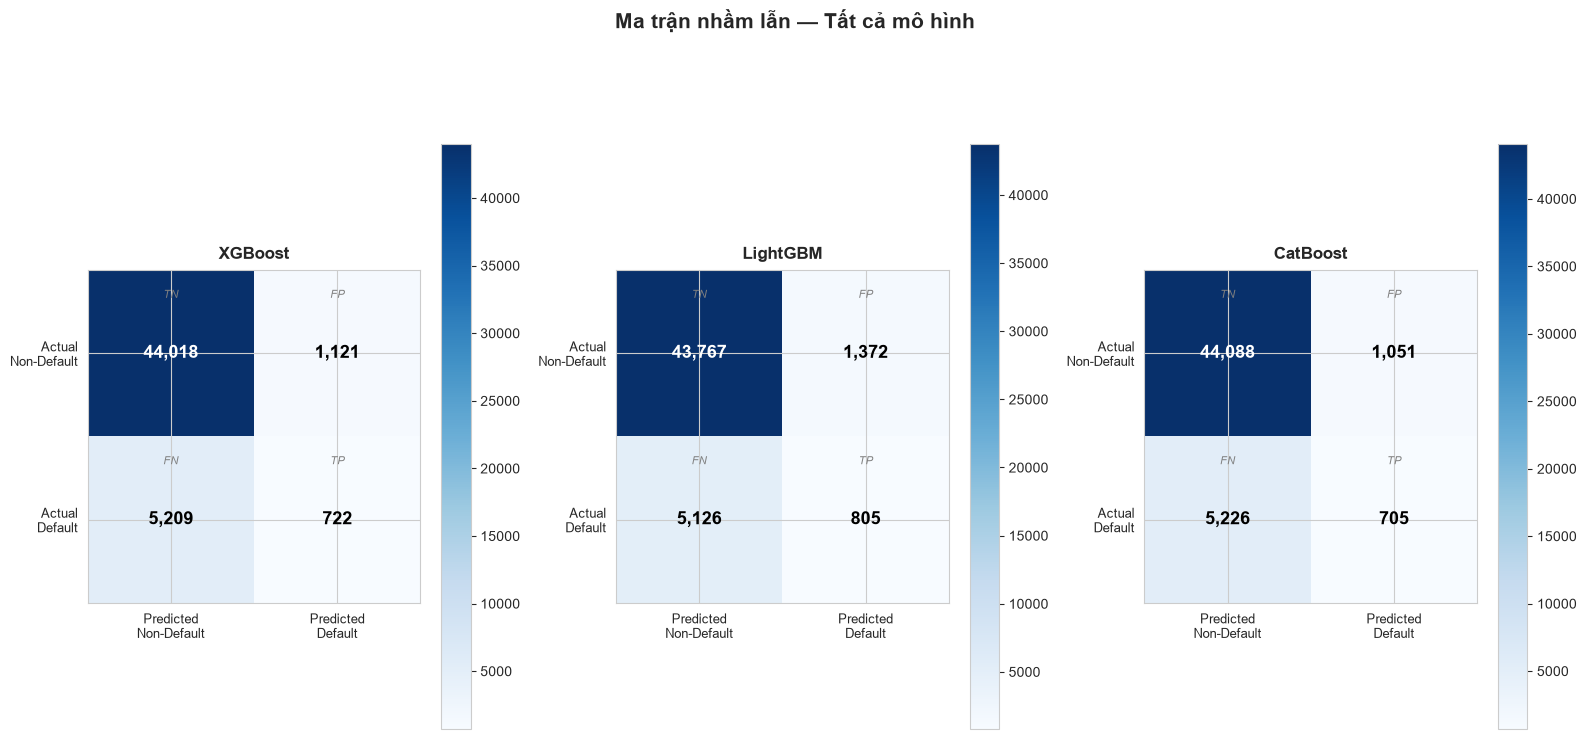

In [12]:
# Tạo figure với 2 hàng, 3 cột
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
axes = axes.flatten()

# Vẽ confusion matrix cho từng model
for i, name in enumerate(MODEL_ORDER):
    cm =results[name]['confusion_matrix']   # Lấy confusion matrix
    ax = axes[i]
    
    # Vẽ heatmap
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold', pad=8)
    plt.colorbar(im, ax=ax, shrink=0.8)
    
    # Thêm số vào các ô
    thresh = cm.max() / 2.
    labels_pos = [['TN', 'FP'], ['FN', 'TP']]
    
    for row in range(2):
        for col in range(2):
            # Số lượng
            ax.text(col, row, f'{cm[row, col]:,}',
                    ha='center', va='center', fontsize=13, fontweight='bold',
                    color='white' if cm[row, col] > thresh else 'black')
            # Nhãn (TN, FP, FN, TP)
            ax.text(col, row - 0.35, labels_pos[row][col],
                    ha='center', va='center', fontsize=8,
                    color='gray', style='italic')
    
    # Cài đặt ticks và labels
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted\nNon-Default', 'Predicted\nDefault'], fontsize=9)
    ax.set_yticklabels(['Actual\nNon-Default', 'Actual\nDefault'], fontsize=9)

# Tiêu đề chính
fig.suptitle('Ma trận nhầm lẫn — Tất cả mô hình', 
             fontsize=15, fontweight='bold', y=1.01)

plt.tight_layout()

save_path = project_root / 'src' / 'reports' / 'figures' / 'confusion_matrices.png'
save_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Figure saved to: {save_path}")

plt.show()

Figure saved to: d:\Python\AIN701_Group_04\demo\src\reports\figures\metrics_comparison.png


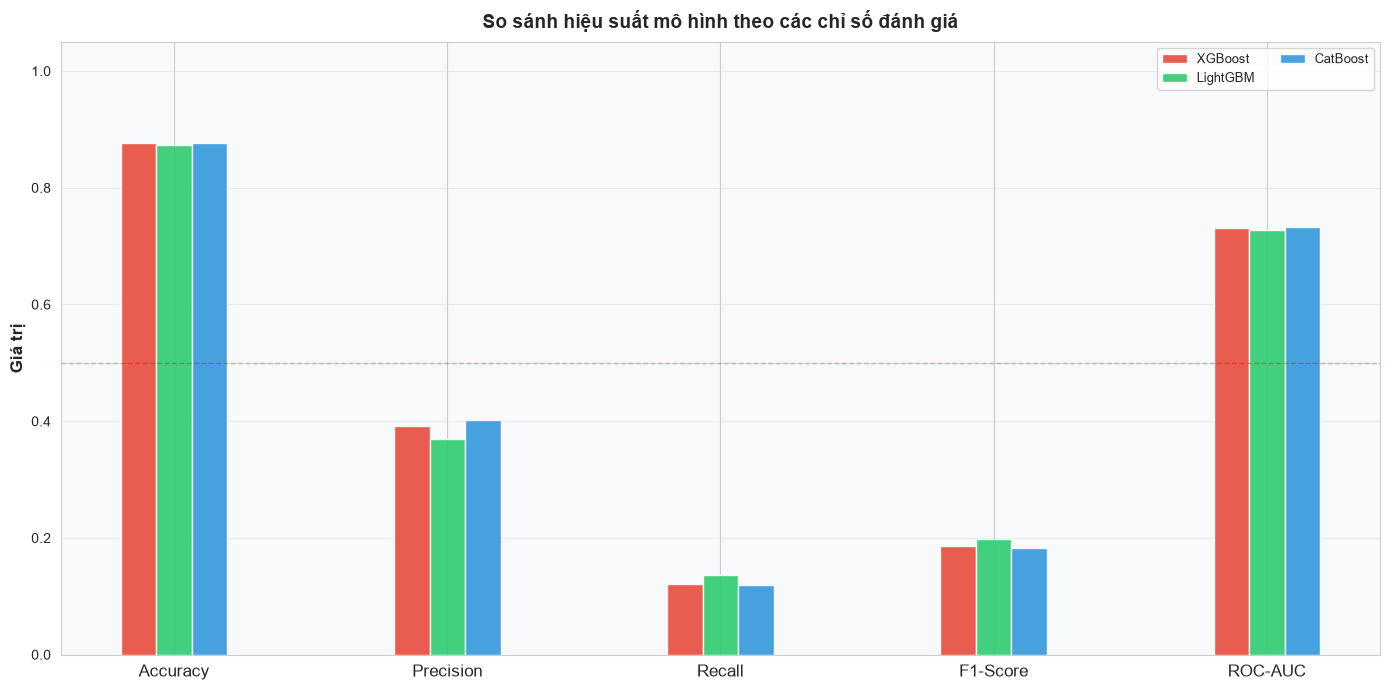

In [13]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.13

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_facecolor('#F8F9FA')

for i, name in enumerate(MODEL_ORDER):
    # SỬA: Truy cập đúng cấu trúc
    vals = [results[name]['metrics'][m] for m in metrics]
    offset = (i - len(MODEL_ORDER)/2 + 0.5) * width
    ax.bar(x + offset, vals, width, label=name,
           color=COLORS[name], edgecolor='white', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Giá trị', fontsize=12, fontweight='bold')
ax.set_title('So sánh hiệu suất mô hình theo các chỉ số đánh giá',
             fontsize=14, fontweight='bold', pad=10)
ax.legend(fontsize=9, ncol=2)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4, linewidth=1)
plt.tight_layout()
save_path = project_root / 'src' / 'reports' / 'figures' / 'metrics_comparison.png'
save_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Figure saved to: {save_path}")
plt.show()